# Furniture Sales Data Analysis Report
**Dataset:** Furniture2.csv (2,500 records, 13 columns)  
**Sections:** Overview → Category/Material → Season/Location → Store Type → Profit → Inventory Risk → Delivery → Correlation → Summary

In [61]:
# ============================================================
# Step 1: Import all libraries & global settings
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Data Overview

In [62]:
# ============================================================
# Step 2: Load dataset
# ============================================================
df = pd.read_csv('Furniture2.csv')

print(f'Dataset size: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
display(df.head(10))

Dataset size: 2500 rows x 14 columns
Columns: ['price', 'cost', 'sales', 'profit', 'inventory', 'delivery_days', 'category', 'material', 'color', 'location', 'season', 'store_type', 'revenue', 'Unnamed: 13']


,price,cost,sales,profit,inventory,delivery_days,category,material,color,location,season,store_type,revenue,Unnamed: 13
0,459,196,2,263,3,30,Bed,Wood,Blue,Urban,Fall,Online,526,nan
1,607,293,4,314,2,58,Bed,Wood,Black,Rural,Fall,Online,1256,nan
2,575,442,4,133,2,58,Bed,Wood,Red,Rural,Spring,Retail,532,nan
3,769,231,6,538,2,82,Bed,Wood,Green,Suburban,Summer,Retail,3228,nan
4,505,267,7,238,2,75,Bed,Leather,Green,Suburban,Summer,Online,1666,nan
5,432,186,7,246,2,77,Bed,Fabric,Blue,Suburban,Winter,Online,1722,nan
6,580,267,7,313,2,40,Bed,Wood,Black,Urban,Spring,Online,2191,nan
7,598,236,8,362,1,57,Bed,Wood,Red,Rural,Summer,Retail,2896,nan
8,1437,227,8,1210,1,37,Bed,Fabric,Blue,Urban,Winter,Retail,9680,nan
9,612,490,9,122,1,76,Bed,Fabric,Red,Rural,Fall,Online,1098,nan


In [63]:
# ============================================================
# Step 3: Data quality check
# ============================================================
print('--- Data Types & Missing Values ---')
df.info()

print('\n--- Missing Value Count ---')
print(df.isnull().sum())

print(f'\n--- Duplicate Rows: {df.duplicated().sum()} ---')

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          2500 non-null   int64  
 1   cost           2500 non-null   int64  
 2   sales          2500 non-null   int64  
 3   profit         2500 non-null   int64  
 4   inventory      2500 non-null   int64  
 5   delivery_days  2500 non-null   int64  
 6   category       2500 non-null   object 
 7   material       2500 non-null   object 
 8   color          2500 non-null   object 
 9   location       2500 non-null   object 
 10  season         2500 non-null   object 
 11  store_type     2500 non-null   object 
 12  revenue        2500 non-null   int64  
 13  Unnamed: 13    168 non-null    float64
dtypes: float64(1), int64(7), object(6)
memory usage: 273.6+ KB

--- Missing Value Count ---
price               0
cost                0
sales           

In [64]:
# ============================================================
# Step 4: Basic statistical summary
# ============================================================
display(df.describe())

# Unique values for each categorical column
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}：{df[col].unique().tolist()}')

,price,cost,sales,profit,inventory,delivery_days,revenue,Unnamed: 13
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,168.00
mean,809.19,393.95,18.51,415.24,2.97,55.43,7323.63,1.57
std,542.01,336.83,12.81,324.32,2.38,19.88,7470.45,1.12
min,124.00,87.00,0.00,-1137.00,0.00,0.00,-26052.00,0.00
25%,528.75,232.75,9.00,222.00,1.00,39.00,2140.50,1.00
50%,682.50,295.00,17.00,353.00,3.00,55.00,5335.00,2.00
75%,914.00,414.00,26.00,531.00,4.00,73.00,10115.50,3.00
max,6989.00,4395.00,98.00,3349.00,10.00,90.00,56925.00,3.00


category：['Bed', 'Chair', 'Desk', 'Dining Table', 'Sofa']
material：['Wood', 'Leather', 'Fabric', 'Metal', 'Plastic', 'Marble', 'Glass']
color：['Blue', 'Black', 'Red', 'Green', 'White', 'Brown']
location：['Urban', 'Rural', 'Suburban']
season：['Fall', 'Spring', 'Summer', 'Winter']
store_type：['Online', 'Retail']


In [65]:
# ============================================================
# Step 5: Build derived features 
# ============================================================

# profit_margin: profit rate (profit column already exists, compute ratio directly)
df['profit_margin'] = df['profit'] / df['price']

# estimated_profit: total profit (unit profit x sales volume)
df['estimated_profit'] = df['profit'] * df['sales']

# cost_price_ratio: ratio of cost to price
df['cost_price_ratio'] = df['cost'] / df['price']

# inventory_sales_ratio: inventory-to-sales ratio (+1 avoids division by zero)
df['inventory_sales_ratio'] = df['inventory'] / (df['sales'] + 1)
df['sales_inventory_ratio'] = df['sales'] / (df['inventory'] + 1)

## 2. Category & Material Analysis

,total_sales,total_revenue,avg_sales,avg_revenue
category,,,,
Sofa,8808,4357368,18.05,8929.03
Desk,8343,3666079,16.65,7317.52
Dining Table,8806,3662505,16.52,6871.49
Bed,8798,3657871,18.29,7604.72
Chair,11532,2965263,23.20,5966.32


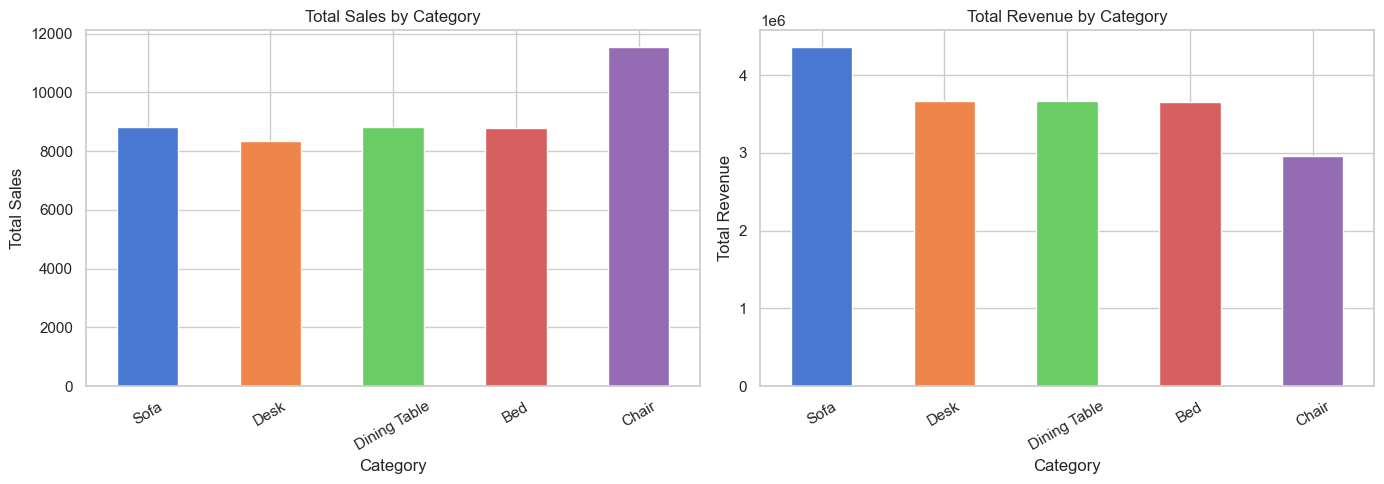

In [66]:
# ============================================================
# Step 6: Category sales & revenue analysis
# ============================================================
category_stats = df.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_revenue', ascending=False)

display(category_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
category_stats['total_sales'].plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(category_stats)))
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=30)

category_stats['total_revenue'].plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', len(category_stats)))
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

,total_sales,total_revenue,avg_sales,avg_revenue
material,,,,
Wood,16281,7342243,18.13,8176.22
Fabric,8485,3220139,19.07,7236.27
Metal,5961,2274091,18.12,6912.13
Marble,4323,1665790,17.50,6744.09
Leather,5544,1631110,21.83,6421.69
Glass,3481,1412620,17.15,6958.72
Plastic,2212,763093,17.84,6153.98


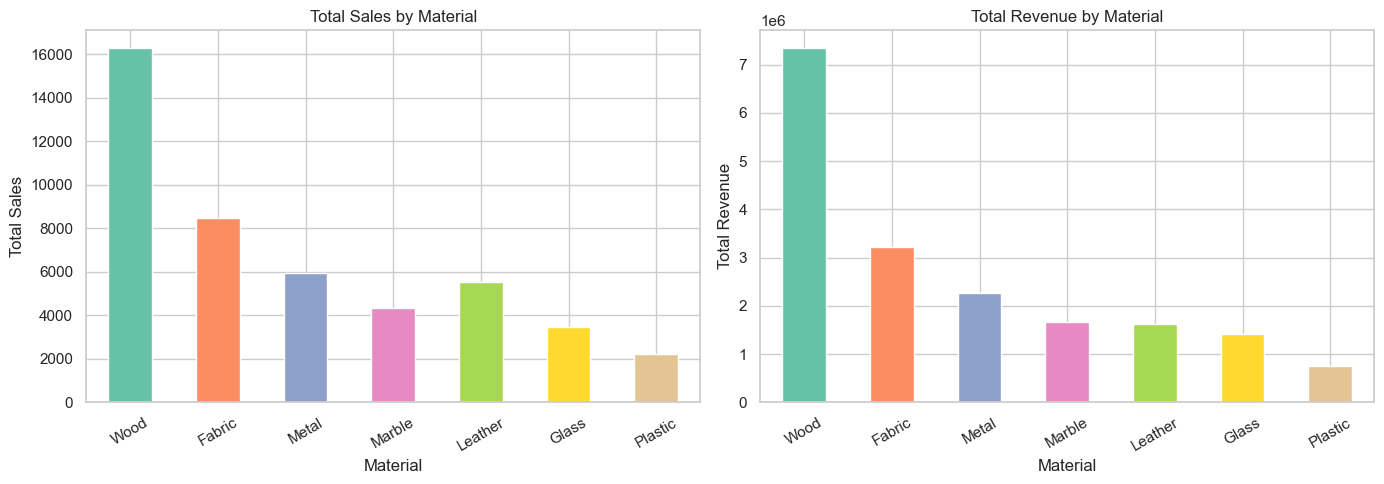

In [67]:
# ============================================================
# Step 7: Material sales & revenue analysis
# ============================================================
material_stats = df.groupby('material').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_revenue', ascending=False)

display(material_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
material_stats['total_sales'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(material_stats)))
axes[0].set_title('Total Sales by Material')
axes[0].set_xlabel('Material')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=30)

material_stats['total_revenue'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', len(material_stats)))
axes[1].set_title('Total Revenue by Material')
axes[1].set_xlabel('Material')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Season & Location Analysis

In [68]:
# ============================================================
# Step 8: Season analysis
# ============================================================
season_stats = df.groupby('season').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_sales', ascending=False)

display(season_stats)

,total_sales,total_revenue,avg_sales,avg_revenue
season,,,,
Winter,12307,4506620,18.90,6922.61
Fall,11752,4659425,18.05,7157.33
Spring,11581,4821345,18.86,7852.35
Summer,10647,4321696,18.23,7400.16


In [69]:
# ============================================================
# Step 9: Location analysis
# ============================================================
location_stats = df.groupby('location').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_sales', ascending=False)

display(location_stats)

,total_sales,total_revenue,avg_sales,avg_revenue
location,,,,
Rural,17080,6868157,19.04,7656.81
Suburban,14750,5806472,18.14,7142.03
Urban,14457,5634457,18.30,7132.22


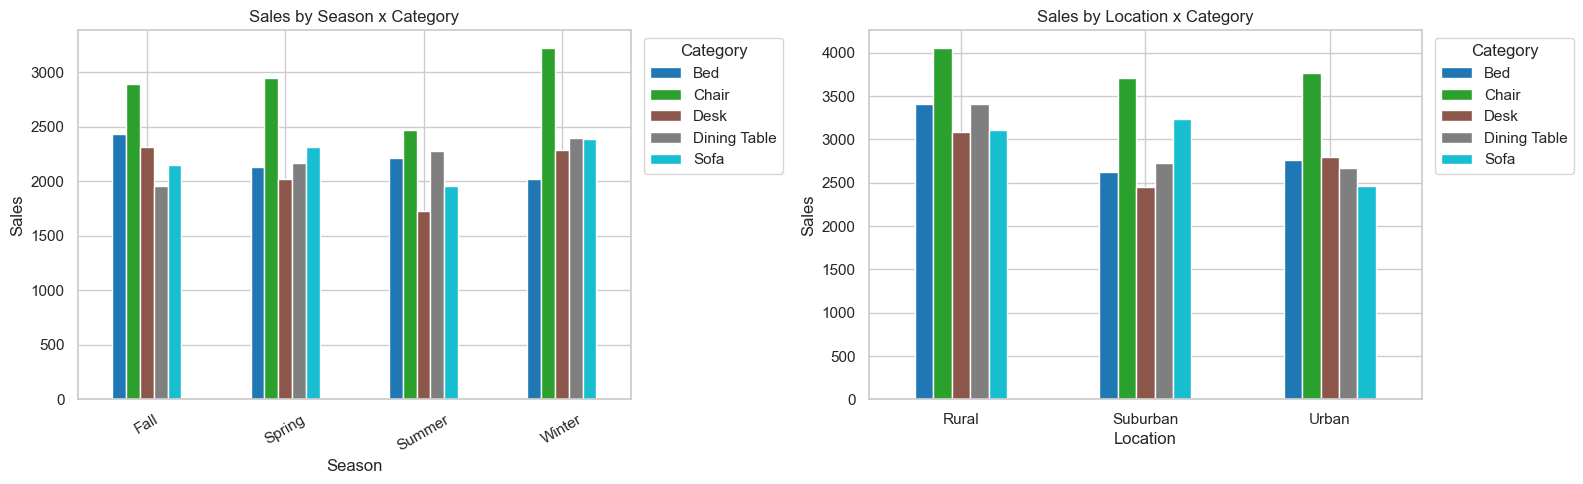

In [70]:
# ============================================================
# Step 10: Season x Category / Location x Category pivot analysis
# ============================================================
season_category = pd.pivot_table(df, values='sales', index='season', columns='category', aggfunc='sum')
location_category = pd.pivot_table(df, values='sales', index='location', columns='category', aggfunc='sum')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

season_category.plot(kind='bar', ax=axes[0], colormap='tab10')
axes[0].set_title('Sales by Season x Category')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Sales')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

location_category.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Sales by Location x Category')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Sales')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Store Type Analysis

,total_sales,total_revenue,avg_sales,avg_revenue,avg_profit_margin,avg_delivery_days
store_type,,,,,,
Online,24373,9298340,18.65,7114.26,0.50,53.30
Retail,21914,9010746,18.37,7553.01,0.49,57.76


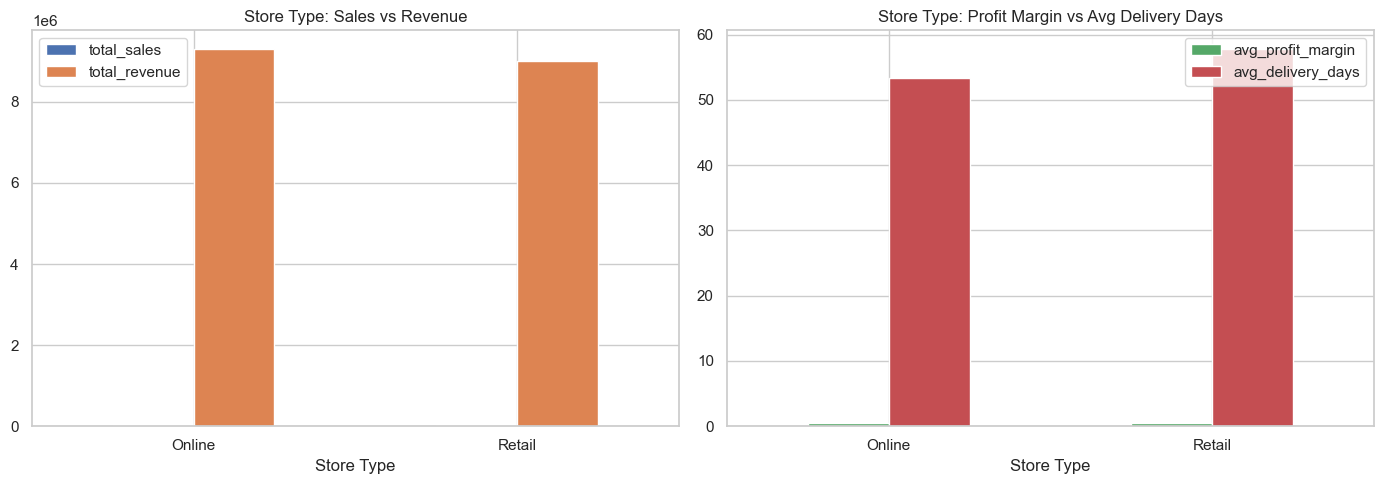

In [71]:
# ============================================================
# Step 11: Online vs Retail store comparison
# ============================================================
store_stats = df.groupby('store_type').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_profit_margin=('profit_margin', 'mean'),
    avg_delivery_days=('delivery_days', 'mean')
).sort_values('total_revenue', ascending=False)

display(store_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

store_stats[['total_sales', 'total_revenue']].plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Store Type: Sales vs Revenue')
axes[0].set_xlabel('Store Type')
axes[0].tick_params(axis='x', rotation=0)

store_stats[['avg_profit_margin', 'avg_delivery_days']].plot(kind='bar', ax=axes[1], color=['#55A868', '#C44E52'])
axes[1].set_title('Store Type: Profit Margin vs Avg Delivery Days')
axes[1].set_xlabel('Store Type')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. Profit Analysis

,avg_profit_margin,avg_cost_price_ratio,total_estimated_profit,avg_estimated_profit
category,,,,
Sofa,0.51,0.49,4357368,8929.03
Desk,0.52,0.48,3666079,7317.52
Dining Table,0.51,0.49,3662505,6871.49
Bed,0.50,0.50,3657871,7604.72
Chair,0.44,0.56,2965263,5966.32


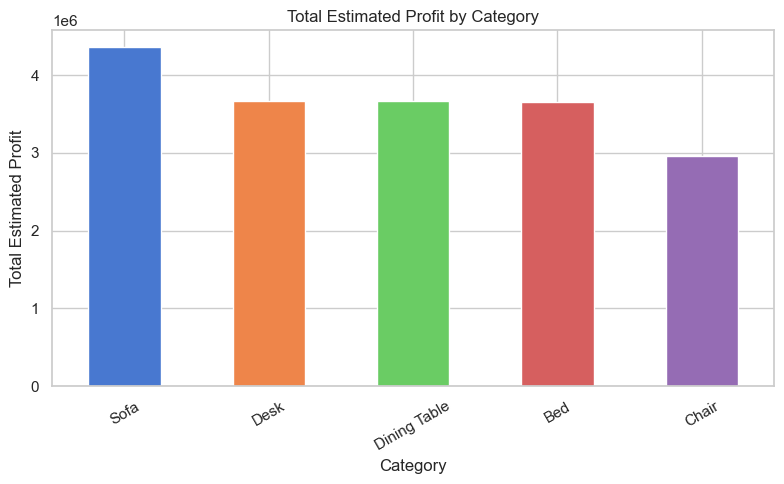

In [72]:
# ============================================================
# Step 12: Profit analysis by category
# ============================================================
profit_by_category = df.groupby('category').agg(
    avg_profit_margin=('profit_margin', 'mean'),
    avg_cost_price_ratio=('cost_price_ratio', 'mean'),
    total_estimated_profit=('estimated_profit', 'sum'),
    avg_estimated_profit=('estimated_profit', 'mean')
).sort_values('total_estimated_profit', ascending=False)

display(profit_by_category)

profit_by_category['total_estimated_profit'].plot(
    kind='bar', figsize=(8, 5), color=sns.color_palette('muted', len(profit_by_category))
)
plt.title('Total Estimated Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Estimated Profit')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# Step 13: Profit analysis by material
# ============================================================
profit_by_material = df.groupby('material').agg(
    avg_profit_margin=('profit_margin', 'mean'),
    avg_cost_price_ratio=('cost_price_ratio', 'mean'),
    total_estimated_profit=('estimated_profit', 'sum'),
    avg_estimated_profit=('estimated_profit', 'mean')
).sort_values('total_estimated_profit', ascending=False)

display(profit_by_material)

,avg_profit_margin,avg_cost_price_ratio,total_estimated_profit,avg_estimated_profit
material,,,,
Wood,0.54,0.46,7342243,8176.22
Fabric,0.48,0.52,3220139,7236.27
Metal,0.49,0.51,2274091,6912.13
Marble,0.49,0.51,1665790,6744.09
Leather,0.36,0.64,1631110,6421.69
Glass,0.50,0.50,1412620,6958.72
Plastic,0.50,0.50,763093,6153.98


In [74]:
# ============================================================
# Step 14: Top 10 highest profit-margin products
# ============================================================
high_profit_products = df.sort_values('profit_margin', ascending=False).head(10)
display(high_profit_products[
    ['category', 'material', 'color', 'store_type', 'location', 'price', 'cost', 'profit_margin', 'sales', 'revenue']
])

,category,material,color,store_type,location,price,cost,profit_margin,sales,revenue
2047,Sofa,Leather,Green,Retail,Urban,1877,152,0.92,33,56925
1630,Dining Table,Marble,Black,Retail,Rural,1960,186,0.91,1,1774
136,Bed,Wood,White,Retail,Suburban,1888,195,0.90,29,49097
1057,Desk,Wood,Brown,Retail,Rural,1370,160,0.88,26,31460
1311,Desk,Metal,Brown,Retail,Suburban,1314,158,0.88,20,23120
1778,Dining Table,Glass,Black,Online,Rural,1278,157,0.88,32,35872
407,Bed,Wood,White,Online,Urban,1308,164,0.87,11,12584
1938,Dining Table,Metal,Black,Retail,Suburban,1239,157,0.87,17,18394
16,Bed,Wood,White,Retail,Suburban,1401,179,0.87,17,20774
649,Chair,Wood,White,Online,Suburban,651,92,0.86,13,7267


In [75]:
# ============================================================
# Step 15: High-revenue but low-margin products (worth reviewing pricing/cost structure)
# ============================================================
high_rev_low_profit = df[
    (df['revenue'] >= df['revenue'].quantile(0.75)) &
    (df['profit_margin'] <= df['profit_margin'].quantile(0.25))
]
display(high_rev_low_profit[
    ['category', 'material', 'price', 'cost', 'sales', 'revenue', 'profit_margin']
].sort_values('revenue', ascending=False).head(10))

,category,material,price,cost,sales,revenue,profit_margin
2312,Sofa,Wood,3575,2283,25,32300,0.36
2087,Sofa,Fabric,3480,2198,23,29486,0.37
1782,Dining Table,Metal,1759,1126,43,27219,0.36
2375,Sofa,Wood,2666,1912,31,23374,0.28
2182,Sofa,Leather,2086,1411,34,22950,0.32
2226,Sofa,Wood,1794,1243,41,22591,0.31
394,Bed,Leather,1836,1130,30,21180,0.38
2229,Sofa,Wood,3343,2168,18,21150,0.35
2092,Sofa,Leather,1895,1186,27,19143,0.37
2390,Sofa,Leather,2025,1468,33,18381,0.28


## 6. Inventory Risk Analysis

Normal            2069
Overstock Risk     225
Stockout Risk      206
Name: inventory_risk, dtype: int64

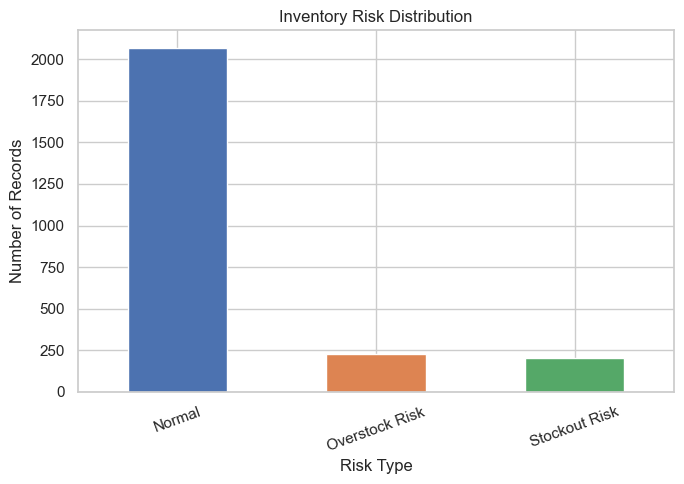

In [76]:
# ============================================================
# Step 16: Inventory risk classification (Overstock / Stockout / Normal)
# ============================================================
sales_high  = df['sales'].quantile(0.75)
sales_low   = df['sales'].quantile(0.25)
inv_high    = df['inventory'].quantile(0.75)
inv_low     = df['inventory'].quantile(0.25)

def classify_inventory(row):
    if row['inventory'] >= inv_high and row['sales'] <= sales_low:
        return 'Overstock Risk'   # high inventory, low sales -> overstock risk
    elif row['inventory'] <= inv_low and row['sales'] >= sales_high:
        return 'Stockout Risk'    # low inventory, high sales -> stockout risk
    else:
        return 'Normal'

df['inventory_risk'] = df.apply(classify_inventory, axis=1)

risk_summary = df['inventory_risk'].value_counts()
display(risk_summary)

risk_summary.plot(kind='bar', figsize=(7, 5), color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Inventory Risk Distribution')
plt.xlabel('Risk Type')
plt.ylabel('Number of Records')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# Step 17: Top 10 overstock risk products
# ============================================================
overstock = df[df['inventory_risk'] == 'Overstock Risk'].sort_values('inventory_sales_ratio', ascending=False)
display(overstock[
    ['category', 'material', 'location', 'store_type', 'inventory', 'sales', 'inventory_sales_ratio', 'profit_margin']
].head(10))

,category,material,location,store_type,inventory,sales,inventory_sales_ratio,profit_margin
485,Chair,Leather,Rural,Retail,8,0,8.00,0.26
182,Bed,Leather,Urban,Retail,6,0,6.00,0.56
1683,Dining Table,Wood,Rural,Online,6,0,6.00,0.45
1684,Dining Table,Wood,Suburban,Retail,6,0,6.00,0.01
1732,Dining Table,Wood,Suburban,Retail,5,0,5.00,0.64
484,Chair,Metal,Urban,Retail,5,0,5.00,-0.17
1733,Dining Table,Metal,Rural,Retail,5,0,5.00,0.74
1731,Dining Table,Marble,Urban,Online,5,0,5.00,0.54
1185,Desk,Wood,Urban,Retail,5,0,5.00,0.58
1184,Desk,Wood,Rural,Online,5,0,5.00,0.61


In [78]:
# ============================================================
# Step 18: Top 10 stockout risk products
# ============================================================
stockout = df[df['inventory_risk'] == 'Stockout Risk'].sort_values('sales_inventory_ratio', ascending=False)
display(stockout[
    ['category', 'material', 'location', 'store_type', 'inventory', 'sales', 'sales_inventory_ratio', 'profit_margin']
].head(10))

,category,material,location,store_type,inventory,sales,sales_inventory_ratio,profit_margin
971,Chair,Leather,Rural,Retail,0,88,88.00,0.58
967,Chair,Fabric,Rural,Retail,0,85,85.00,0.63
1478,Desk,Metal,Rural,Online,0,52,52.00,0.74
2011,Dining Table,Marble,Urban,Online,0,51,51.00,0.28
2010,Dining Table,Marble,Rural,Retail,0,49,49.00,0.65
1477,Desk,Glass,Suburban,Online,0,47,47.00,0.01
1476,Desk,Glass,Rural,Retail,0,46,46.00,0.50
1682,Dining Table,Wood,Urban,Online,0,45,45.00,0.29
970,Chair,Leather,Urban,Online,1,88,44.00,0.09
2009,Dining Table,Marble,Urban,Online,0,44,44.00,0.78


In [79]:
# ============================================================
# Step 19: Inventory overview by category
# ============================================================
inventory_by_category = df.groupby('category').agg(
    total_inventory=('inventory', 'sum'),
    total_sales=('sales', 'sum'),
    avg_inventory=('inventory', 'mean'),
    avg_sales=('sales', 'mean'),
    avg_inventory_sales_ratio=('inventory_sales_ratio', 'mean')
).sort_values('avg_inventory_sales_ratio', ascending=False)

display(inventory_by_category)

,total_inventory,total_sales,avg_inventory,avg_sales,avg_inventory_sales_ratio
category,,,,,
Chair,2492,11532,5.01,23.20,0.42
Dining Table,1329,8806,2.49,16.52,0.32
Desk,1212,8343,2.42,16.65,0.26
Bed,1209,8798,2.51,18.29,0.26
Sofa,1193,8808,2.44,18.05,0.21


## 7. Delivery Analysis

,avg_delivery_days,median_delivery_days,max_delivery_days,order_count
location,,,,
Suburban,55.74,56,90,813
Rural,55.30,55,90,897
Urban,55.25,54,90,790


,avg_delivery_days,median_delivery_days,max_delivery_days,order_count
store_type,,,,
Retail,57.76,58,90,1193
Online,53.30,53,90,1307


,avg_delivery_days,median_delivery_days,max_delivery_days,order_count
category,,,,
Sofa,57.48,58,90,488
Dining Table,56.98,56,90,533
Desk,56.37,56,90,501
Chair,54.82,55,90,497
Bed,51.26,50,90,481


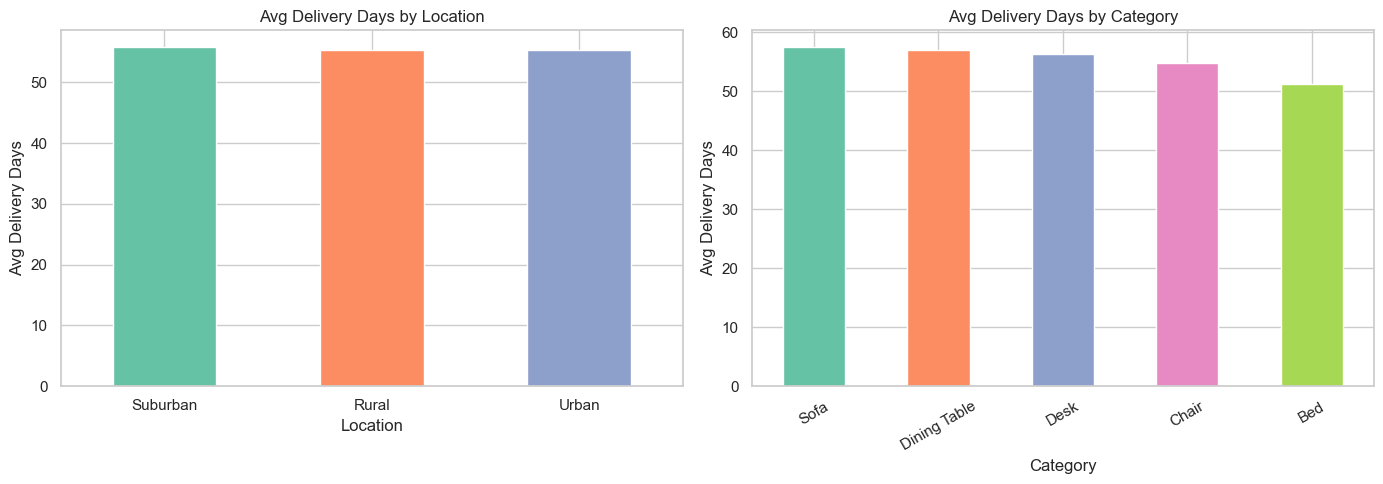

In [80]:
# ============================================================
# Step 20: Delivery days analysis across dimensions
# ============================================================
def delivery_agg(group_col):
    return df.groupby(group_col).agg(
        avg_delivery_days=('delivery_days', 'mean'),
        median_delivery_days=('delivery_days', 'median'),
        max_delivery_days=('delivery_days', 'max'),
        order_count=('delivery_days', 'count')
    ).sort_values('avg_delivery_days', ascending=False)

delivery_by_location   = delivery_agg('location')
delivery_by_store_type = delivery_agg('store_type')
delivery_by_category   = delivery_agg('category')

display(delivery_by_location)
display(delivery_by_store_type)
display(delivery_by_category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
delivery_by_location['avg_delivery_days'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(delivery_by_location)))
axes[0].set_title('Avg Delivery Days by Location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Avg Delivery Days')
axes[0].tick_params(axis='x', rotation=0)

delivery_by_category['avg_delivery_days'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', len(delivery_by_category)))
axes[1].set_title('Avg Delivery Days by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Delivery Days')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [81]:
# ============================================================
# Step 21: Delivery delay risk (orders > 60 days flagged as delayed)
# ============================================================
df['delay_risk'] = np.where(df['delivery_days'] > 60, 1, 0)

delay_by_location = df.groupby('location').agg(
    delay_rate=('delay_risk', 'mean'),
    avg_delivery_days=('delivery_days', 'mean')
).sort_values('delay_rate', ascending=False)

display(delay_by_location)

,delay_rate,avg_delivery_days
location,,
Rural,0.42,55.30
Urban,0.42,55.25
Suburban,0.41,55.74


## 8. Correlation Analysis

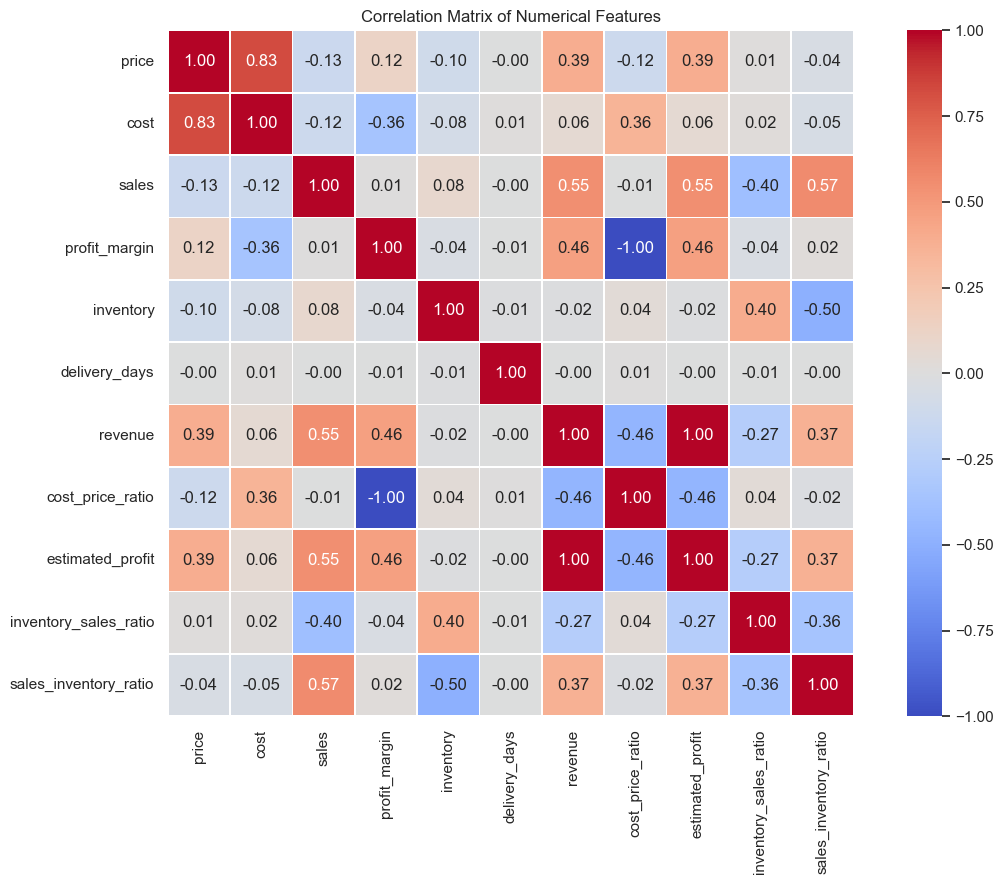

In [82]:
# ============================================================
# Step 22: Correlation heatmap (seaborn with annotated values)
# ============================================================
numeric_cols = [
    'price', 'cost', 'sales', 'profit_margin', 'inventory',
    'delivery_days', 'revenue', 'cost_price_ratio',
    'estimated_profit', 'inventory_sales_ratio', 'sales_inventory_ratio'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,          # show values in cells
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 9. Summary & Conclusions

In [83]:
# ============================================================
# Step 23: Key metrics summary
# ============================================================
print('=' * 50)
print('  Furniture Sales - Key Metrics Summary')
print('=' * 50)

print(f'\n[Category]')
print(f'  Highest sales: {category_stats["total_sales"].idxmax()}')
print(f'  Highest revenue: {category_stats["total_revenue"].idxmax()}')
print(f'  Highest profit: {profit_by_category["total_estimated_profit"].idxmax()}')

print(f'\n[Material]')
print(f'  Highest revenue: {material_stats["total_revenue"].idxmax()}')
print(f'  Highest profit: {profit_by_material["total_estimated_profit"].idxmax()}')

print(f'\n[Season & Location]')
print(f'  Peak sales season: {season_stats["total_sales"].idxmax()}')
print(f'  Highest sales location: {location_stats["total_sales"].idxmax()}')

print(f'\n[Store Type]')
print(f'  Highest revenue: {store_stats["total_revenue"].idxmax()}')

print(f'\n[Inventory Risk]')
print(f'  Overstock risk records: {(df["inventory_risk"] == "Overstock Risk").sum()}')
print(f'  Stockout risk records: {(df["inventory_risk"] == "Stockout Risk").sum()}')

print(f'\n[Delivery]')
print(f'  Slowest delivery location: {delivery_by_location["avg_delivery_days"].idxmax()}')
print(f'  Slowest delivery category: {delivery_by_category["avg_delivery_days"].idxmax()}')

  Furniture Sales - Key Metrics Summary

[Category]
  Highest sales: Chair
  Highest revenue: Sofa
  Highest profit: Sofa

[Material]
  Highest revenue: Wood
  Highest profit: Wood

[Season & Location]
  Peak sales season: Winter
  Highest sales location: Rural

[Store Type]
  Highest revenue: Online

[Inventory Risk]
  Overstock risk records: 225
  Stockout risk records: 206

[Delivery]
  Slowest delivery location: Suburban
  Slowest delivery category: Sofa


## 10. Predictive Replenishment Recommendation Algorithm

This section implements the SmartSCM replenishment recommendation algorithm. The algorithm uses a two-stage design:

1. **Demand prediction:** A Random Forest Regression model predicts product-level sales demand.
2. **Replenishment decision:** An explainable reorder rule compares forecasted demand during lead time plus safety stock against available and incoming inventory.

This hybrid design is suitable for the capstone prototype because it combines machine learning with a clear business rule that can be explained to store owners and sales staff.

In [84]:
# ============================================================
# Step 24: Prepare data for machine learning demand prediction
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# Make a copy so the modeling section does not accidentally change the original analysis table
model_df = df.copy()

# Target variable: sales volume
# IMPORTANT: Do not use revenue as a feature when predicting sales because revenue is usually calculated from price x sales.
# Using revenue would cause data leakage and make the model look unrealistically strong.
target_col = 'sales'

# Candidate features for demand prediction
categorical_features = [
    'category',
    'material',
    'color',
    'location',
    'store_type',
    'season'
]

numeric_features = [
    'price',
    'cost',
    'profit',
    'inventory',
    'delivery_days',
    'profit_margin',
    'cost_price_ratio'
]

# Keep only features that exist in the current dataset
categorical_features = [col for col in categorical_features if col in model_df.columns]
numeric_features = [col for col in numeric_features if col in model_df.columns]
feature_cols = categorical_features + numeric_features

# Drop rows with missing target values
model_df = model_df.dropna(subset=[target_col]).copy()

X = model_df[feature_cols]
y = model_df[target_col]

print('Target variable:', target_col)
print('Categorical features:', categorical_features)
print('Numeric features:', numeric_features)
print('Modeling dataset shape:', X.shape)


Target variable: sales
Categorical features: ['category', 'material', 'color', 'location', 'store_type', 'season']
Numeric features: ['price', 'cost', 'profit', 'inventory', 'delivery_days', 'profit_margin', 'cost_price_ratio']
Modeling dataset shape: (2500, 13)


In [85]:
# ============================================================
# Step 25: Train Random Forest Regression model
# ============================================================

# OneHotEncoder handles categorical variables such as category, material, color, and location.
# handle_unknown='ignore' prevents errors when new product categories appear in future data.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

demand_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

demand_model.fit(X_train, y_train)
y_pred = demand_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Random Forest Demand Prediction Performance')
print(f'MAE : {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²  : {r2:.3f}')


Random Forest Demand Prediction Performance
MAE : 9.99
RMSE: 11.84
R²  : -0.077


In [86]:
# ============================================================
# Step 26: Feature importance for explainability
# ============================================================

# Get feature names after one-hot encoding
encoded_cat_names = demand_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_names) + numeric_features

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': demand_model.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

print('Top 15 Important Features for Demand Prediction')
display(feature_importance.head(15))

feature_importance.head(15).sort_values('importance').plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(9, 6),
    legend=False
)
plt.title('Top Feature Importance for Demand Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


AttributeError: 'OneHotEncoder' object has no attribute 'get_feature_names_out'

### Replenishment Rule

The predicted sales demand is converted into a replenishment recommendation using the following rule:

**Reorder Recommended = Forecasted Demand During Lead Time + Safety Stock > Available Inventory + Incoming Inventory**

The suggested reorder quantity is calculated as:

**Suggested Reorder Quantity = Forecasted Demand During Lead Time + Safety Stock - Available Inventory - Incoming Inventory**

If the result is less than or equal to zero, the system does not recommend replenishment.

In [ ]:
# ============================================================
# Step 27: Define replenishment recommendation function
# ============================================================

def build_replenishment_recommendations(
    data,
    trained_model,
    feature_columns,
    demand_period_days=30,
    replenishment_lead_time_days=60,
    safety_stock_days=14,
    minimum_order_quantity=1
):
    """
    Build product-level replenishment recommendations using a hybrid method:
    1. Random Forest predicts sales demand for a historical demand period.
    2. Rule-based logic decides whether to reorder.

    Parameters
    ----------
    data : pandas.DataFrame
        Product-level dataset.
    trained_model : sklearn Pipeline
        Trained demand prediction model.
    feature_columns : list
        Feature columns used by the trained model.
    demand_period_days : int
        Number of days represented by the sales target. For example, if sales means monthly sales, use 30.
    replenishment_lead_time_days : int
        Estimated number of days from placing a supplier order to receiving the inventory.
        Cross-border furniture retail may use 45-90 days depending on production, shipping, customs, and local delivery.
    safety_stock_days : int
        Extra protection days used to reduce stockout risk.
    minimum_order_quantity : int
        Minimum quantity to recommend when reorder is needed.

    Returns
    -------
    pandas.DataFrame
        DataFrame with forecasted demand, safety stock, reorder decision, suggested reorder quantity, and priority score.
    """

    result = data.copy()

    # Predict sales demand for the same period represented by the training target.
    result['predicted_period_sales'] = trained_model.predict(result[feature_columns])
    result['predicted_period_sales'] = result['predicted_period_sales'].clip(lower=0)

    # Convert period demand into daily demand, then into demand during replenishment lead time.
    result['predicted_daily_sales'] = result['predicted_period_sales'] / demand_period_days
    result['forecasted_demand_during_lead_time'] = result['predicted_daily_sales'] * replenishment_lead_time_days

    # Add optional inventory status columns if the current dataset does not include them yet.
    # These columns match the future SmartSCM multi-status inventory design.
    default_inventory_cols = {
        'local_warehouse': result['inventory'] if 'inventory' in result.columns else 0,
        'showroom': 0,
        'reserved_inventory': 0,
        'in_production': 0,
        'in_transit': 0
    }

    for col, default_value in default_inventory_cols.items():
        if col not in result.columns:
            result[col] = default_value

    # Available inventory = local warehouse + showroom - reserved quantity.
    result['available_inventory'] = (
        result['local_warehouse'] + result['showroom'] - result['reserved_inventory']
    ).clip(lower=0)

    # Incoming inventory = inventory already in production or transit.
    result['incoming_inventory'] = result['in_production'] + result['in_transit']

    # Safety stock based on predicted daily demand and safety stock coverage days.
    result['safety_stock'] = result['predicted_daily_sales'] * safety_stock_days

    # Reorder point and gap.
    result['reorder_point'] = result['forecasted_demand_during_lead_time'] + result['safety_stock']
    result['inventory_supply'] = result['available_inventory'] + result['incoming_inventory']
    result['reorder_gap'] = result['reorder_point'] - result['inventory_supply']

    # Reorder recommendation.
    result['reorder_recommended'] = result['reorder_gap'] > 0
    result['suggested_reorder_quantity'] = np.where(
        result['reorder_recommended'],
        np.ceil(result['reorder_gap']).astype(int),
        0
    )

    # Apply minimum order quantity only when reorder is recommended.
    result.loc[
        result['reorder_recommended'] & (result['suggested_reorder_quantity'] < minimum_order_quantity),
        'suggested_reorder_quantity'
    ] = minimum_order_quantity

    # Priority score combines shortage pressure, predicted demand, profit margin, and delivery time.
    # This score is not the reorder decision itself. It only helps rank recommended items.
    max_gap = result['reorder_gap'].clip(lower=0).max()
    max_pred_sales = result['predicted_period_sales'].max()
    max_delivery = result['delivery_days'].max() if 'delivery_days' in result.columns else 1

    result['shortage_pressure_score'] = np.where(max_gap > 0, result['reorder_gap'].clip(lower=0) / max_gap, 0)
    result['demand_score'] = np.where(max_pred_sales > 0, result['predicted_period_sales'] / max_pred_sales, 0)
    result['profit_score'] = result['profit_margin'].clip(lower=0) if 'profit_margin' in result.columns else 0
    result['delivery_risk_score'] = result['delivery_days'] / max_delivery if 'delivery_days' in result.columns and max_delivery > 0 else 0

    result['replenishment_priority_score'] = (
        0.45 * result['shortage_pressure_score'] +
        0.30 * result['demand_score'] +
        0.15 * result['profit_score'] +
        0.10 * result['delivery_risk_score']
    )

    # Business-friendly decision label
    result['replenishment_decision'] = np.select(
        [
            result['reorder_recommended'] & (result['replenishment_priority_score'] >= 0.70),
            result['reorder_recommended'] & (result['replenishment_priority_score'] >= 0.40),
            result['reorder_recommended']
        ],
        [
            'High Priority Reorder',
            'Medium Priority Reorder',
            'Low Priority Reorder'
        ],
        default='No Reorder Needed'
    )

    return result


In [ ]:
# ============================================================
# Step 28: Generate replenishment recommendations
# ============================================================

recommendation_df = build_replenishment_recommendations(
    data=model_df,
    trained_model=demand_model,
    feature_columns=feature_cols,
    demand_period_days=30,              # Treat sales as demand during a 30-day period for the prototype
    replenishment_lead_time_days=60,    # Example cross-border replenishment lead time
    safety_stock_days=14,               # Extra buffer to reduce stockout risk
    minimum_order_quantity=1
)

recommendation_cols = [
    'category', 'material', 'color', 'location', 'store_type', 'season',
    'price', 'cost', 'profit_margin',
    'inventory', 'available_inventory', 'incoming_inventory',
    'predicted_period_sales', 'forecasted_demand_during_lead_time', 'safety_stock',
    'reorder_point', 'inventory_supply', 'reorder_gap',
    'reorder_recommended', 'suggested_reorder_quantity',
    'replenishment_priority_score', 'replenishment_decision'
]

recommendation_cols = [col for col in recommendation_cols if col in recommendation_df.columns]

replenishment_table = recommendation_df[recommendation_cols].sort_values(
    ['reorder_recommended', 'replenishment_priority_score', 'suggested_reorder_quantity'],
    ascending=[False, False, False]
)

print('Top 20 Replenishment Recommendations')
display(replenishment_table.head(20))


Top 20 Replenishment Recommendations


,category,material,color,location,store_type,season,price,cost,profit_margin,inventory,available_inventory,incoming_inventory,predicted_period_sales,forecasted_demand_during_lead_time,safety_stock,reorder_point,inventory_supply,reorder_gap,reorder_recommended,suggested_reorder_quantity,replenishment_priority_score,replenishment_decision
552,Chair,Metal,Green,Suburban,Online,Summer,616,240,0.61,7,7,0,42.96,85.93,20.05,105.98,7,98.98,True,99,0.91,High Priority Reorder
586,Chair,Plastic,White,Urban,Online,Spring,471,250,0.47,5,5,0,41.39,82.79,19.32,102.10,5,97.10,True,98,0.86,High Priority Reorder
490,Chair,Plastic,Blue,Urban,Retail,Summer,487,217,0.55,3,3,0,39.55,79.09,18.46,97.55,3,94.55,True,95,0.86,High Priority Reorder
536,Chair,Metal,Blue,Urban,Online,Winter,608,235,0.61,4,4,0,38.43,76.85,17.93,94.78,4,90.78,True,91,0.84,High Priority Reorder
2294,Bed,Plastic,Green,Rural,Retail,Spring,986,201,0.80,5,5,0,34.83,69.66,16.25,85.92,5,80.92,True,81,0.82,High Priority Reorder
376,Chair,Plastic,Blue,Urban,Retail,Spring,498,176,0.65,5,5,0,36.52,73.05,17.04,90.09,5,85.09,True,86,0.82,High Priority Reorder
125,Chair,Wood,Green,Rural,Retail,Winter,302,276,0.09,4,4,0,40.16,80.32,18.74,99.06,4,95.06,True,96,0.81,High Priority Reorder
576,Chair,Wood,Black,Suburban,Online,Summer,474,246,0.48,1,1,0,35.77,71.54,16.69,88.23,1,87.23,True,88,0.80,High Priority Reorder
371,Chair,Glass,White,Suburban,Online,Spring,334,174,0.48,2,2,0,36.79,73.58,17.17,90.75,2,88.75,True,89,0.80,High Priority Reorder
547,Chair,Wood,Red,Urban,Retail,Fall,620,238,0.62,10,10,0,36.79,73.58,17.17,90.74,10,80.74,True,81,0.79,High Priority Reorder


,product_count,avg_predicted_sales,avg_reorder_gap,total_suggested_reorder_quantity,avg_priority_score
replenishment_decision,,,,,
High Priority Reorder,82,33.53,78.57,6484,0.75
Medium Priority Reorder,1499,21.03,47.18,71479,0.51
Low Priority Reorder,919,12.66,25.78,24150,0.32


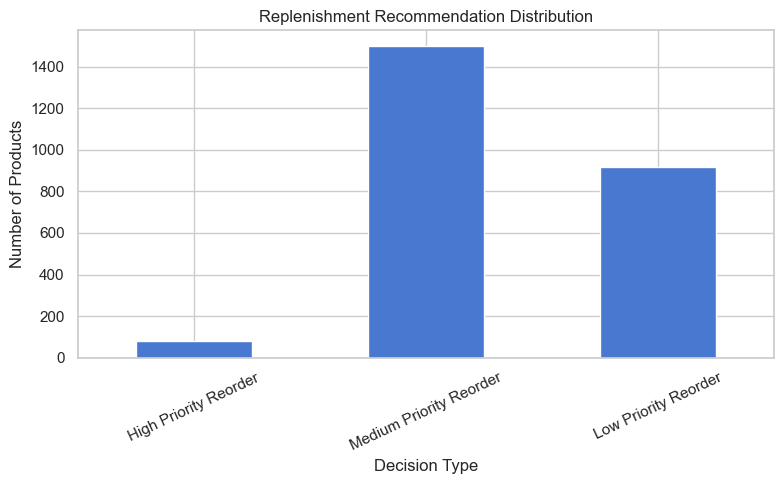

In [ ]:
# ============================================================
# Step 29: Replenishment recommendation summary
# ============================================================

replenishment_summary = recommendation_df.groupby('replenishment_decision').agg(
    product_count=('replenishment_decision', 'count'),
    avg_predicted_sales=('predicted_period_sales', 'mean'),
    avg_reorder_gap=('reorder_gap', 'mean'),
    total_suggested_reorder_quantity=('suggested_reorder_quantity', 'sum'),
    avg_priority_score=('replenishment_priority_score', 'mean')
).sort_values('avg_priority_score', ascending=False)

display(replenishment_summary)

# Recommendation count chart
replenishment_summary['product_count'].plot(kind='bar', figsize=(8, 5))
plt.title('Replenishment Recommendation Distribution')
plt.xlabel('Decision Type')
plt.ylabel('Number of Products')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


,products,recommended_products,total_suggested_reorder_quantity,avg_predicted_sales,avg_reorder_gap,avg_priority_score,recommendation_rate
category,,,,,,,
Chair,497,497,23876,21.31,47.55,0.50,1.00
Sofa,488,488,20005,18.41,40.49,0.45,1.00
Bed,481,481,19847,18.56,40.77,0.45,1.00
Dining Table,533,533,19423,16.62,35.94,0.41,1.00
Desk,501,501,18962,17.05,37.34,0.42,1.00


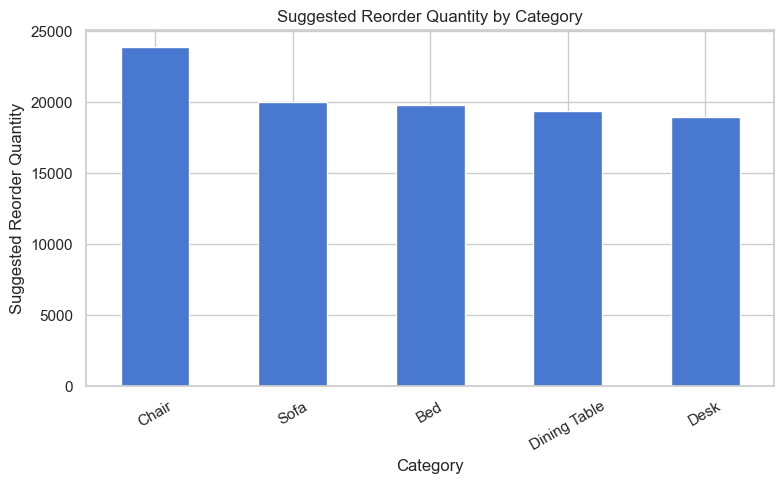

In [ ]:
# ============================================================
# Step 30: Category-level replenishment planning view
# ============================================================

category_replenishment = recommendation_df.groupby('category').agg(
    products=('category', 'count'),
    recommended_products=('reorder_recommended', 'sum'),
    total_suggested_reorder_quantity=('suggested_reorder_quantity', 'sum'),
    avg_predicted_sales=('predicted_period_sales', 'mean'),
    avg_reorder_gap=('reorder_gap', 'mean'),
    avg_priority_score=('replenishment_priority_score', 'mean')
).sort_values('total_suggested_reorder_quantity', ascending=False)

category_replenishment['recommendation_rate'] = (
    category_replenishment['recommended_products'] / category_replenishment['products']
)

display(category_replenishment)

category_replenishment['total_suggested_reorder_quantity'].plot(kind='bar', figsize=(8, 5))
plt.title('Suggested Reorder Quantity by Category')
plt.xlabel('Category')
plt.ylabel('Suggested Reorder Quantity')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Step 31: Export recommendation output for SmartSCM prototype
# ============================================================

output_file = 'smartscm_replenishment_recommendations.csv'
replenishment_table.to_csv(output_file, index=False)

print(f'Replenishment recommendation file exported: {output_file}')
print('This output can be connected to the SmartSCM Replenishment Recommendation page.')


Replenishment recommendation file exported: smartscm_replenishment_recommendations.csv
This output can be connected to the SmartSCM Replenishment Recommendation page.


### Algorithm Interpretation for the Capstone Report

The implemented algorithm provides an explainable way to recommend replenishment. The Random Forest model estimates product-level demand using product attributes, pricing, cost, inventory, delivery, store, location, and seasonal information. The reorder rule then checks whether the forecasted demand during the replenishment lead time plus safety stock is greater than the available and incoming inventory. If the required inventory is greater than the current supply, the system recommends replenishment and calculates a suggested reorder quantity.

This design is suitable for SmartSCM because it avoids a black-box reorder decision. The machine learning model supports demand estimation, while the final recommendation remains transparent and easy for a small business owner to understand.